### Logic Gate Network

**Imports**

In [1]:
import numpy as np
from scipy.special import softmax
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

**Logic operators**

In [2]:
def op_false(a, b): 
    return np.zeros_like(a)

def op_and(a, b): 
    return a * b

def op_not_imp_ab(a, b): 
    return a - a*b

def op_A(a, b): 
    return a

def op_not_imp_ba(a, b): 
    return b - a*b

def op_B(a, b): 
    return b

def op_xor(a, b): 
    return a + b - 2*a*b

def op_or(a, b): 
    return a + b - a*b

def op_not_or(a, b): 
    return 1 - (a + b - a*b)

def op_xnor(a, b): 
    return 1 - (a + b - 2*a*b)

def op_notB(a, b): 
    return 1 - b

def op_leqA(a, b): 
    return 1 - b + a*b

def op_notA(a, b): 
    return 1 - a

def op_implAB(a, b): 
    return 1 - a + a*b

def op_not_and(a, b): 
    return 1 - a*b

def op_true(a, b): 
    return np.ones_like(a)

def counted_operators(a, b):
    return np.stack([
        op_false(a,b),
        op_and(a, b),
        op_not_imp_ab(a, b),
        op_A(a, b),
        op_not_imp_ba(a, b),
        op_B(a, b),
        op_xor(a, b), 
        op_or(a, b),
        op_not_or(a, b), 
        op_xnor(a, b),
        op_notB(a, b),
        op_leqA(a, b), 
        op_notA(a, b),
        op_implAB(a, b),
        op_not_and(a, b),
        op_true(a, b),
    ], axis=0)

**Logic Net**

In [3]:
class LogicNeuron:
    def __init__(self, in_features):
        self.i1 = np.random.randint(in_features)
        self.i2 = np.random.choice([i for i in range(in_features) if i != self.i1])
        self.logits = np.random.randn(16) * 0.5                  

    def forward(self, x, temp=2.0):
        a = x[..., self.i1]
        b = x[..., self.i2]
        ops = counted_operators(a, b)
        p = softmax(self.logits / temp)[:, None]
        self.cache = (ops, p, a, b)
        return np.sum(ops * p, axis=0)

    def backward(self, grad_out, temp=2.0):
        ops, p, _, _ = self.cache
        expected = np.sum(ops * p, axis=0, keepdims=True)
        grad_logits = np.sum((ops - expected) * grad_out[None, :], axis=1) / temp
        return grad_logits            
    
class LogicLayer:
    def __init__(self, in_features, out_features):
        self.neurons = [LogicNeuron(in_features) for _ in range(out_features)]
        self.out_features = out_features

    def forward(self, x):
        return np.stack([n.forward(x) for n in self.neurons], axis=-1) 

    def backward(self, grad_out):
        return [n.backward(grad_out[:, i]) for i, n in enumerate(self.neurons)]

class LogicNet:
    def __init__(self, input_bits, layers=[32,32], n_classes=2, outputs_per_class=6, tau=0.1):
        self.layers = []
        in_f = input_bits
        for out_f in layers:
            self.layers.append(LogicLayer(in_f, out_f))
            in_f = out_f

        self.out_layer = LogicLayer(in_f, outputs_per_class * n_classes)
        self.n_classes = n_classes
        self.opc = outputs_per_class
        self.tau = tau
        self.params = [n.logits for layer in self.layers + [self.out_layer] for n in layer.neurons]

    def forward(self, x):
        h = x.astype(np.float32)
        for layer in self.layers:
            h = layer.forward(h)
        h = self.out_layer.forward(h)
        scores = h.reshape(-1, self.n_classes, self.opc).sum(axis=2) / self.tau
        return scores

    def backward(self, scores, y):
        batch = scores.shape[0]
        exp_s = np.exp(scores - scores.max(axis=1, keepdims=True))
        probs = exp_s / exp_s.sum(axis=1, keepdims=True)
        grad_scores = probs.copy()
        grad_scores[np.arange(batch), y] -= 1
        grad_scores /= batch

        grad_out = np.zeros((batch, self.out_layer.out_features))
        for c in range(self.n_classes):
            grad_out[:, c*self.opc:(c+1)*self.opc] = grad_scores[:, c][:, None] / self.opc

        return self.out_layer.backward(grad_out)

    def fit(self, X, y, epochs=2000, lr=0.15):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.int64)

        m = [np.zeros_like(p) for p in self.params]
        v = [np.zeros_like(p) for p in self.params]
        beta1, beta2 = 0.9, 0.999

        for ep in range(1, epochs+1):
            scores = self.forward(X)
            grads = self.backward(scores, y)

            for i, g in enumerate(grads):
                m[i] = beta1*m[i] + (1-beta1)*g
                v[i] = beta2*v[i] + (1-beta2)*(g*g)
                self.params[i][:] -= lr * m[i] / (np.sqrt(v[i]) + 1e-8)

            if ep % 200 == 0 or ep == 1:
                full_scores = self.forward(X)
                acc = accuracy_score(y, full_scores.argmax(axis=1))
                print(f"Epoka {ep:4d} | Acc: {acc:.3f}")
        

    def predict(self, X):
        return self.forward(X).argmax(axis=1)
    

**Test**

=== START TRENINGU ===
Epoka    1 | Acc: 0.500
Epoka  200 | Acc: 0.500
Epoka  400 | Acc: 0.500
Epoka  600 | Acc: 0.500
Epoka  800 | Acc: 0.500
Epoka 1000 | Acc: 0.500
Epoka 1200 | Acc: 0.500
Epoka 1400 | Acc: 0.500
Epoka 1600 | Acc: 0.500
Epoka 1800 | Acc: 0.500
Epoka 2000 | Acc: 0.500

Predykcje: [1 1 1 1 1 1 1 1]
Prawda:    [0 1 1 0 1 0 0 1]
Final accuracy: 50.0%


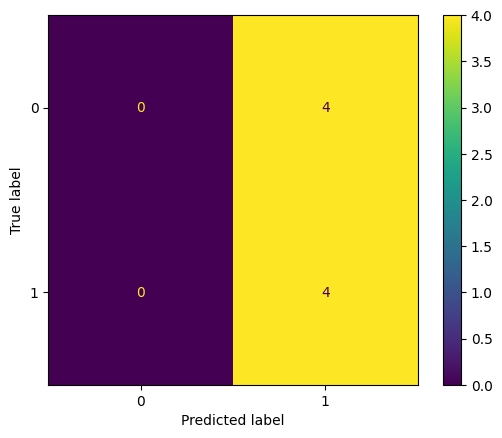

In [4]:
X = np.array([
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
])

y = np.array([0,1,1,0,1,0,0,1])

model = LogicNet(
    layers=[16, 16], 
    input_bits=3, 
    outputs_per_class=8,
    tau=2.0
    )

print("=== START TRENINGU ===")
model.fit(X, y, epochs=2000, lr=0.1)

pred = model.predict(X)
print("\nPredykcje:", pred)
print("Prawda:   ", y)
print(f"Final accuracy: {accuracy_score(y, pred)*100:.1f}%")
ConfusionMatrixDisplay.from_predictions(y, pred)